In [134]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,confusion_matrix,accuracy_score, precision_score, recall_score, f1_score,fbeta_score, roc_curve, roc_auc_score, precision_recall_curve,auc, average_precision_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDRegressor, SGDClassifier, Ridge, Lasso
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from sklearn.preprocessing import TargetEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from category_encoders import LeaveOneOutEncoder
from sklearn.ensemble import RandomForestRegressor
from scipy import stats ##
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.inspection import permutation_importance
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import cross_val_score

In [135]:
df = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\bmw.csv') 
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0
...,...,...,...,...,...,...,...,...,...
10776,X3,2016,19000,Automatic,40818,Diesel,150,54.3,2.0
10777,5 Series,2016,14600,Automatic,42947,Diesel,125,60.1,2.0
10778,3 Series,2017,13100,Manual,25468,Petrol,200,42.8,2.0
10779,1 Series,2014,9930,Automatic,45000,Diesel,30,64.2,2.0


In [136]:
df=df.drop_duplicates(subset=None, keep='first', inplace=False, ignore_index=False)
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0
...,...,...,...,...,...,...,...,...,...
10776,X3,2016,19000,Automatic,40818,Diesel,150,54.3,2.0
10777,5 Series,2016,14600,Automatic,42947,Diesel,125,60.1,2.0
10778,3 Series,2017,13100,Manual,25468,Petrol,200,42.8,2.0
10779,1 Series,2014,9930,Automatic,45000,Diesel,30,64.2,2.0


In [137]:
X = df.drop('price', axis=1)

In [138]:
y=df['price']

In [139]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=True)

In [140]:
## Находим категориальные столбцы
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

#Создаём encoder
encoder = LeaveOneOutEncoder(cols=cat_cols,sigma=0.1)

In [141]:
# Обучаем encoder только на train (как я понял чтобы не модель не брала данные из test)
X_train_enc = encoder.fit_transform(X_train, y_train)

# Преобразуем test
X_test_enc = encoder.transform(X_test)

In [142]:
X_test_enc

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
6941,45105.000000,2020,27433.948787,3000,21848.267118,145,34.9,3.0
9162,15808.978385,2016,14506.882530,36681,21848.267118,0,83.1,1.5
4167,22597.370466,2018,27433.948787,6173,24320.296840,150,41.5,3.0
3150,15808.978385,2016,14506.882530,10937,21848.267118,30,65.7,2.0
584,22701.542857,2018,27433.948787,13197,27657.055556,140,156.9,2.0
...,...,...,...,...,...,...,...,...
3725,26523.258824,2019,27433.948787,1817,24320.296840,145,38.7,2.0
6746,70030.622222,2019,27433.948787,5000,21848.267118,145,33.6,3.0
2558,22597.370466,2019,27433.948787,5656,21848.267118,150,50.4,3.0
4197,15808.978385,2019,14506.882530,101,24320.296840,145,53.3,1.5


In [143]:
'''from sklearn.base import BaseEstimator, TransformerMixin


class MeanTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y):
        X = X.copy()
        df = X.copy()
        df[" target "] = y.values

        self.global_mean_ = y.mean()
        self.mapping_ = {}

        for col in self.cols:
            self.mapping_[col] = df.groupby(col)[" target "].mean().to_dict()

        return self

    def transform(self, X):
        X = X.copy()

        for col in self.cols:
            X[col] = X[col].map(self.mapping_[col])
            X[col] = X[col].fillna(self.global_mean_)

        return X

# Загружаем данные
df = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\bmw.csv')

target = "price"

# Признаки и цель
X = df.drop(columns=[target])
y = df[target]

# Кодируем нужные столбцы
encoder = MeanTargetEncoder(cols=["model", "transmission", "fuelType"])

X_train_enc = encoder.fit_transform(X_train, y_train)
X_test_enc = encoder.transform(X_test)'''




'from sklearn.base import BaseEstimator, TransformerMixin\n\n\nclass MeanTargetEncoder(BaseEstimator, TransformerMixin):\n    def __init__(self, cols):\n        self.cols = cols\n\n    def fit(self, X, y):\n        X = X.copy()\n        df = X.copy()\n        df[" target "] = y.values\n\n        self.global_mean_ = y.mean()\n        self.mapping_ = {}\n\n        for col in self.cols:\n            self.mapping_[col] = df.groupby(col)[" target "].mean().to_dict()\n\n        return self\n\n    def transform(self, X):\n        X = X.copy()\n\n        for col in self.cols:\n            X[col] = X[col].map(self.mapping_[col])\n            X[col] = X[col].fillna(self.global_mean_)\n\n        return X\n\n# Загружаем данные\ndf = pd.read_csv(\'C:\\Users\\User\\Documents\\ДЗ\\bmw.csv\')\n\ntarget = "price"\n\n# Признаки и цель\nX = df.drop(columns=[target])\ny = df[target]\n\n# Кодируем нужные столбцы\nencoder = MeanTargetEncoder(cols=["model", "transmission", "fuelType"])\n\nX_train_enc = encod

In [144]:
mean = X_train_enc.mean(axis=0)
std = X_train_enc.std(axis=0, ddof=0)


z_train = np.abs((X_train_enc - mean) / std)
mask_train = (z_train < 3).all(axis=1)

X_train_enc = X_train_enc[mask_train]
y_train = y_train[mask_train]

z_test = np.abs((X_test_enc - mean) / std)
mask_test = (z_test < 3).all(axis=1)

X_test_enc = X_test_enc[mask_test]
y_test = y_test[mask_test]

In [172]:
# Обучаем модель
model = LinearRegression()

model.fit(X_train_enc, y_train)

# Предсказание
y_pred = model.predict(X_test_enc)

# Метрики
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 17296934.23952191
MAE: 2932.2357953844694
R2: 0.8288255609027155


In [147]:
cross_val_score(model,X_train_enc, y_train, cv=5).mean()

np.float64(0.8209887903834112)

In [149]:
## Подбор оптимальных гиперпараметров для линейной регрессии

In [150]:
from sklearn.linear_model import SGDRegressor

In [151]:
scaler = StandardScaler()
X_train_scl = pd.DataFrame(scaler.fit_transform(X_train_enc), columns=X_train_enc.columns)
X_test_scl = pd.DataFrame(scaler.transform(X_test_enc), columns=X_test_enc.columns)

In [152]:
model1 = SGDRegressor(
    loss="squared_error",  ## Функция ошибки 
    penalty="l1", ## Регуляризация
    alpha=21.54,  ## Сила регуляризации
    learning_rate="adaptive", ## по мере обучения шаг уменьшается
    eta0=0.1, ## Начальный шаг обучения
    max_iter=5000,## макс. колво итераций
    tol=1e-4, ## допуск для остановки кода
    random_state=42
)

In [153]:
model1.fit(X_train_scl, y_train)

# Предсказание
y_pred1 = model1.predict(X_test_scl)

# Метрики
print("MSE:", mean_squared_error(y_test, y_pred1))
print("R2:", r2_score(y_test, y_pred1))

MSE: 17296747.1992051
R2: 0.8288274118967052


In [48]:
## Подбор гиперпараметров 
##Сетка параметров
alpha_grid2 = np.logspace(-4,4,10)
param_grid2 = {
    'alpha':alpha_grid2,
    'loss': ['squared_error', 'huber'],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'learning_rate': ['invscaling', 'adaptive'],
    'eta0': [0.01, 0.05, 0.1]
}   
    
##Поиск лучших параметров
grid2 = GridSearchCV(
    estimator=model1,
    param_grid=param_grid2,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

In [51]:
grid2.fit(X_train_scl, y_train)

Fitting 5 folds for each of 360 candidates, totalling 1800 fits


,estimator,"SGDRegressor(...2, tol=0.0001)"
,param_grid,"{'alpha': array([1.0000...00000000e+04]), 'eta0': [0.01, 0.05, ...], 'learning_rate': ['invscaling', 'adaptive'], 'loss': ['squared_error', 'huber'], ...}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [154]:
print('Оптимальные гиперпараметры',grid2.best_params_)

Оптимальные гиперпараметры {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [155]:
## Обучаем случайным лесом

<Axes: >

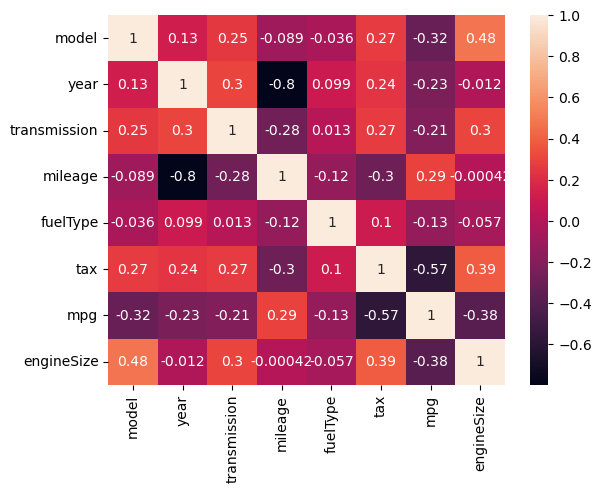

In [156]:
sns.heatmap(X_train_enc.corr(), annot=True)

<Axes: >

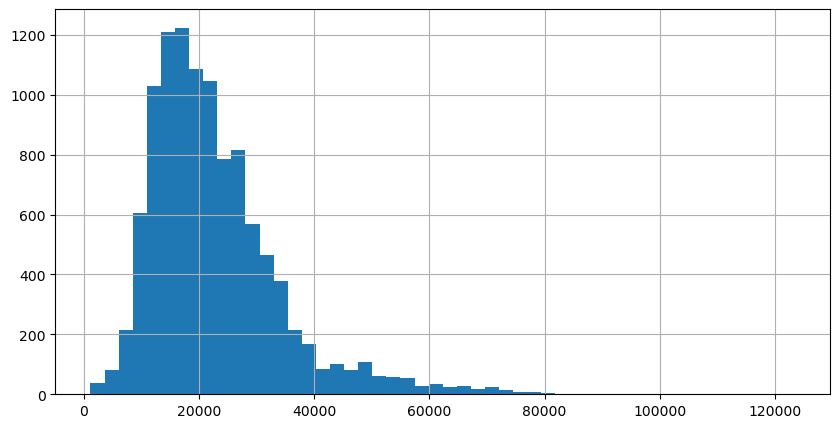

In [173]:
## Гистограмма распределения price
y.hist(bins=50,figsize=(10,5))

In [158]:
## Распределение нормальное, но имеющий длинный хвост. -> Лучше испльзовать MAE или Huber loss

In [169]:
model2 = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    min_samples_leaf=1,
    min_samples_split=2,
    n_jobs=-1
)

model2.fit(X_train_scl, y_train)
y_pred2 = model2.predict(X_test_scl)

print("MAE:",  mean_absolute_error(y_test, y_pred2))
print("R2:", r2_score(y_test, y_pred2))

MAE: 1733.0003678273663
R2: 0.9202705768726992


In [170]:
cross_val_score(model2,X_train_scl, y_train, cv=5).mean()

np.float64(0.9073709236567318)

In [175]:
## Оценка наиболее важных параметров для модели
importances2 = pd.Series(model2.feature_importances_, index=X_train_scl.columns)
print(importances2.sort_values(ascending=False).head(10))

year            0.289753
mileage         0.209227
engineSize      0.175320
model           0.171706
mpg             0.066946
tax             0.037662
transmission    0.033429
fuelType        0.015957
dtype: float64


In [161]:
## Подбор гиперпараметров 
##Сетка параметров
param_grid = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [None, 5, 10, 15, 20],
    "max_features": ["sqrt", "log2", ],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
}

##Поиск лучших параметров
grid = GridSearchCV(
    estimator=model2,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=2
)

In [167]:
grid.fit(X_train_scl, y_train)

Fitting 5 folds for each of 640 candidates, totalling 3200 fits


,estimator,ExtraTreesReg...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [168]:
grid.best_params_

{'max_depth': None,
 'max_features': 'log2',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 300}

## Итого по результатам обуччения двух моделей лучше предсказывает модель случайного леса (это показывают метрики MAE, R2, а также результаты кроссвалидации)
## наиболее влияющую на таргет параметры оказались год , пробег , объем двигателя  машины и модель

In [30]:
##Уровень 2

In [233]:
bmw = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\bmw.csv') 
audi = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\audi.csv')  
ford = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\ford.csv')
hyundi = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\hyundi.csv')
skoda = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\skoda.csv')
toyota = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\toyota.csv')
cclass = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\cclass.csv')
focus = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\focus.csv')
merc = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\merc.csv')
vw = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\vw.csv')
vauxhall = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\vauxhall.csv')

In [234]:
## объединяем все в один датафрейм
df2 = pd.concat([bmw,audi,ford,hyundi,skoda,toyota,cclass,focus,merc,vw,vauxhall],axis=0,ignore_index=True)
df2

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,tax(£)
0,5 Series,2014,11200,Automatic,67068,Diesel,125.0,57.6,2.0,NaN
1,6 Series,2018,27000,Automatic,14827,Petrol,145.0,42.8,2.0,NaN
2,5 Series,2016,16000,Automatic,62794,Diesel,160.0,51.4,3.0,NaN
3,1 Series,2017,12750,Automatic,26676,Diesel,145.0,72.4,1.5,NaN
4,7 Series,2014,14500,Automatic,39554,Diesel,160.0,50.4,3.0,NaN
...,...,...,...,...,...,...,...,...,...,...
108535,Tigra,2007,2499,Manual,48640,Petrol,165.0,46.3,1.4,NaN
108536,Vectra,2007,1795,Manual,75000,Petrol,240.0,39.2,1.8,NaN
108537,Vectra,2005,1495,Manual,74000,Petrol,235.0,38.7,1.8,NaN
108538,Vectra,2008,1695,Automatic,131000,Diesel,200.0,39.8,1.9,NaN


In [235]:
df2=df2.drop_duplicates(subset=None, keep='first', inplace=False, ignore_index=False)


In [236]:
df2.isna().sum()

model                0
year                 0
price                0
transmission         0
mileage              0
fuelType             0
tax              13329
mpg               8555
engineSize           0
tax(£)          101493
dtype: int64

In [237]:
df2['tax']=df2['tax'].fillna(df2['tax(£)']*100/73) ## Видно что указан налог либо в фунтах дибо в долларах - не придумал ничего лучше чем сделать просто один стобец переведя фунты в доллары
df2.isna().sum() 



C:\Users\User\AppData\Local\Temp\ipykernel_18832\3839928034.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['tax']=df2['tax'].fillna(df2['tax(£)']*100/73) ## Видно что указан налог либо в фунтах дибо в долларах - не придумал ничего лучше чем сделать просто один стобец переведя фунты в доллары


model                0
year                 0
price                0
transmission         0
mileage              0
fuelType             0
tax               8555
mpg               8555
engineSize           0
tax(£)          101493
dtype: int64

In [238]:
df2.drop(['tax(£)'], axis=1, inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_18832\4273385867.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.drop(['tax(£)'], axis=1, inplace=True)


In [239]:
df2.isna().sum()

model              0
year               0
price              0
transmission       0
mileage            0
fuelType           0
tax             8555
mpg             8555
engineSize         0
dtype: int64

In [240]:
## Видим, что  пропущенные значения Nan есть только в марках merc и focus при чем не вовсех столбцах -> можно заменить на средние значения имеющихся данных в этих марках

In [241]:
df2['tax']=df2['tax'].fillna(df2.groupby(['model', 'year'])['tax'].transform('median'))
df2['mpg']=df2['mpg'].fillna(df2.groupby(['model', 'year'])['mpg'].transform('median'))

C:\Users\User\AppData\Local\Temp\ipykernel_18832\3415091303.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['tax']=df2['tax'].fillna(df2.groupby(['model', 'year'])['tax'].transform('median'))
C:\Users\User\AppData\Local\Temp\ipykernel_18832\3415091303.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['mpg']=df2['mpg'].fillna(df2.groupby(['model', 'year'])['mpg'].transform('median'))


In [242]:
df2.isna().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             5
mpg             5
engineSize      0
dtype: int64

In [243]:
##решил просто удалить ибо 5 значений  в таком большом датасете не должны сильно повлиять на прогноз
df2=df2.dropna()
df2

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125.0,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145.0,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160.0,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145.0,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160.0,50.4,3.0
...,...,...,...,...,...,...,...,...,...
108535,Tigra,2007,2499,Manual,48640,Petrol,165.0,46.3,1.4
108536,Vectra,2007,1795,Manual,75000,Petrol,240.0,39.2,1.8
108537,Vectra,2005,1495,Manual,74000,Petrol,235.0,38.7,1.8
108538,Vectra,2008,1695,Automatic,131000,Diesel,200.0,39.8,1.9


In [244]:
from catboost import CatBoostRegressor

In [245]:
X = df2.drop('price', axis=1)

In [246]:
y=df2['price']

In [247]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=True)

In [248]:
cat_features2 = X_train.select_dtypes(include=['object']).columns.tolist()

In [249]:
cat_features2

['model', 'transmission', 'fuelType']

In [250]:
'''model3 = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.5,
    depth=8,
    loss_function='MAE',
    random_seed=42,
    verbose=100
)'''

"model3 = CatBoostRegressor(\n    iterations=1000,\n    learning_rate=0.5,\n    depth=8,\n    loss_function='MAE',\n    random_seed=42,\n    verbose=100\n)"

In [251]:
'''model3.fit(
    X_train, y_train,
    cat_features=cat_features2)'''

'model3.fit(\n    X_train, y_train,\n    cat_features=cat_features2)'

In [252]:
'''## Делаем прогноз
y_pred = model3.predict(X_test)

## Считаем метрики
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"R2: {r2}")'''

'## Делаем прогноз\ny_pred = model3.predict(X_test)\n\n## Считаем метрики\nmse = mean_squared_error(y_test, y_pred)\nr2 = r2_score(y_test, y_pred)\n\nprint(f"MSE: {mse}")\nprint(f"R2: {r2}")'

In [253]:
## Пробуем обучить через CatBoostEncoder

In [254]:
'''from category_encoders import CatBoostEncoder
cat_features = df2[["model", "transmission", "fuelType"]]
encoder = CatBoostEncoder(cols=cat_features)

_IncompleteInputError: incomplete input (4090184943.py, line 1)

In [255]:
'''# Кодируем только train
X_train_enc1 = encoder.fit_transform(X_train, y_train)
X_test_enc1 = encoder.transform(X_test)

# Обучаем модель
model4 = RandomForestRegressor(random_state=42)
model4.fit(X_train_enc1, y_train)

# Предсказание
y_pred_enc = model4.predict(X_test_enc1)
r2_enc = r2_score(y_test, y_pred_enc)
# Оценка
print("MSE:", mean_squared_error(y_test, y_pred_enc))
print("R2:", r2_enc)
'''


'# Кодируем только train\nX_train_enc1 = encoder.fit_transform(X_train, y_train)\nX_test_enc1 = encoder.transform(X_test)\n\n# Обучаем модель\nmodel4 = RandomForestRegressor(random_state=42)\nmodel4.fit(X_train_enc1, y_train)\n\n# Предсказание\ny_pred_enc = model4.predict(X_test_enc1)\nr2_enc = r2_score(y_test, y_pred_enc)\n# Оценка\nprint("MSE:", mean_squared_error(y_test, y_pred_enc))\nprint("R2:", r2_enc)\n'

In [256]:
## теперь повторяем обучение линейной регрессии и случайнго леса для датафрейма с объединенными марками машин

In [257]:
'''class MeanTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y):
        X = X.copy()
        df = X.copy()
        df[" target "] = y.values

        self.global_mean_ = y.mean()
        self.mapping_ = {}

        for col in self.cols:
            self.mapping_[col] = df.groupby(col)[" target "].mean().to_dict()

        return self

    def transform(self, X):
        X = X.copy()

        for col in self.cols:
            X[col] = X[col].map(self.mapping_[col])
            X[col] = X[col].fillna(self.global_mean_)

        return X

# Загружаем данные
df = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\bmw.csv')

target = "price"

# Признаки и цель
X = df.drop(columns=[target])
y = df[target]

# Делим train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Кодируем нужные столбцы
encoder = MeanTargetEncoder(cols=["model", "transmission", "fuelType"])

X_train_enc = encoder.fit_transform(X_train, y_train)
X_test_enc = encoder.transform(X_test)

# Если есть ещё текстовые столбцы — убираем их
X_train_enc = X_train_enc.select_dtypes(include="number")
X_test_enc = X_test_enc.select_dtypes(include="number")
'''


'class MeanTargetEncoder(BaseEstimator, TransformerMixin):\n    def __init__(self, cols):\n        self.cols = cols\n\n    def fit(self, X, y):\n        X = X.copy()\n        df = X.copy()\n        df[" target "] = y.values\n\n        self.global_mean_ = y.mean()\n        self.mapping_ = {}\n\n        for col in self.cols:\n            self.mapping_[col] = df.groupby(col)[" target "].mean().to_dict()\n\n        return self\n\n    def transform(self, X):\n        X = X.copy()\n\n        for col in self.cols:\n            X[col] = X[col].map(self.mapping_[col])\n            X[col] = X[col].fillna(self.global_mean_)\n\n        return X\n\n# Загружаем данные\ndf = pd.read_csv(\'C:\\Users\\User\\Documents\\ДЗ\\bmw.csv\')\n\ntarget = "price"\n\n# Признаки и цель\nX = df.drop(columns=[target])\ny = df[target]\n\n# Делим train/test\nX_train, X_test, y_train, y_test = train_test_split(\n    X, y, test_size=0.2, random_state=42\n)\n\n# Кодируем нужные столбцы\nencoder = MeanTargetEncoder(cols=["

In [258]:
## Находим категориальные столбцы
cat_cols2 = X.select_dtypes(include=["object"]).columns.tolist()

#Создаём encoder
encoder2 = LeaveOneOutEncoder(cols=cat_cols2)

In [259]:
# Обучаем encoder только на train (как я понял чтобы не модель не брала данные из test)
X_train_enc2 = encoder2.fit_transform(X_train, y_train)

# Преобразуем test
X_test_enc2 = encoder2.transform(X_test)

In [260]:
mean2 = X_train_enc2.mean(axis=0)
std2 = X_train_enc2.std(axis=0, ddof=0)


z_train2 = np.abs((X_train_enc2 - mean2) / std2)
mask_train2 = (z_train2 < 3).all(axis=1)

X_train_enc2 = X_train_enc2[mask_train2]
y_train = y_train[mask_train2]

z_test2 = np.abs((X_test_enc2 - mean2) / std2)
mask_test2 = (z_test2 < 3).all(axis=1)

X_test_enc2 = X_test_enc2[mask_test2]
y_test = y_test[mask_test2]

<Axes: >

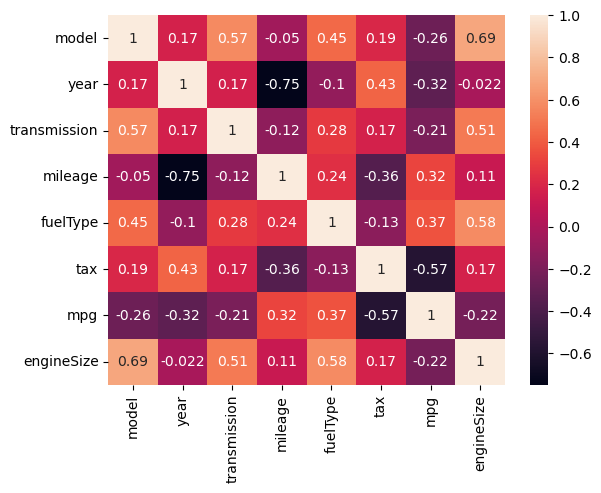

In [261]:
sns.heatmap(X_train_enc2.corr(), annot=True)

<Axes: >

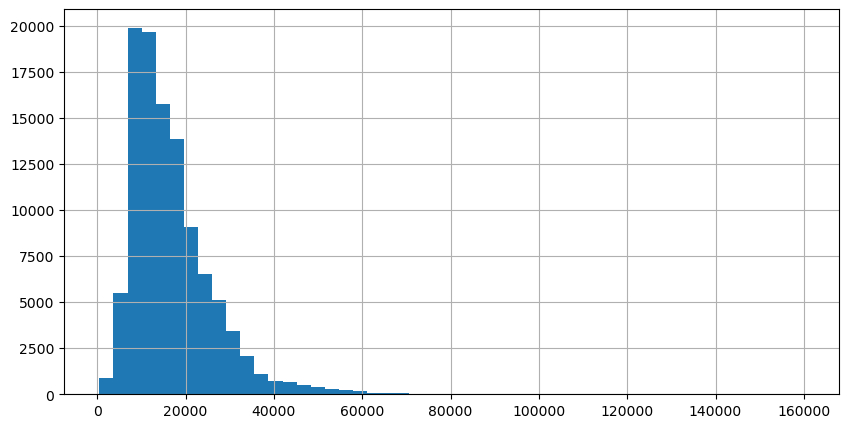

In [262]:
## Гистограмма распределения price
y.hist(bins=50,figsize=(10,5))

In [263]:
## Распределение price выглядит схожим с первым заданием

In [264]:
model3 = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.5,
    depth=8,
    loss_function='MAE',
    random_seed=42,
    verbose=100
)

In [265]:
model3.fit(
    X_train_enc2, y_train)
## Делаем прогноз
y_pred = model3.predict(X_test_enc2)

## Считаем метрики
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R2: {r2}")

0:	learn: 3973.9473087	total: 6.46ms	remaining: 6.46s
100:	learn: 253.5537684	total: 626ms	remaining: 5.57s
200:	learn: 177.0542713	total: 1.21s	remaining: 4.81s
300:	learn: 143.6036664	total: 1.79s	remaining: 4.15s
400:	learn: 128.0473940	total: 2.36s	remaining: 3.53s
500:	learn: 115.5463876	total: 2.94s	remaining: 2.93s
600:	learn: 106.1200737	total: 3.52s	remaining: 2.34s
700:	learn: 100.2157413	total: 4.1s	remaining: 1.75s
800:	learn: 95.1563767	total: 4.71s	remaining: 1.17s
900:	learn: 91.7506259	total: 5.3s	remaining: 583ms
999:	learn: 88.5639836	total: 5.87s	remaining: 0us
MSE: 54882016.86668612
MAE: 5750.195342724305
R2: 0.18519446775725246


In [229]:
result_cat = permutation_importance(model3, X_test_enc2, y_test, n_repeats=10, random_state=42)

In [266]:
feature_names_cat=X_test_enc2.columns
importance_df_cat = pd.DataFrame({
    "feature": feature_names_cat,
    "importance_mean": result_lin.importances_mean, ## Cреднее падение качества модели
    "importance_std": result_lin.importances_std ## Cтандартное отклонение важности
}).sort_values("importance_mean", ascending=False)
importance_df_lin

,feature,importance_mean,importance_std
0,model,0.394224,0.003310
1,year,0.199443,0.002497
7,engineSize,0.140967,0.001866
3,mileage,0.079604,0.001356
6,mpg,0.033552,0.000759
2,transmission,0.023333,0.000604
5,tax,0.017598,0.000628
4,fuelType,0.000603,0.000092


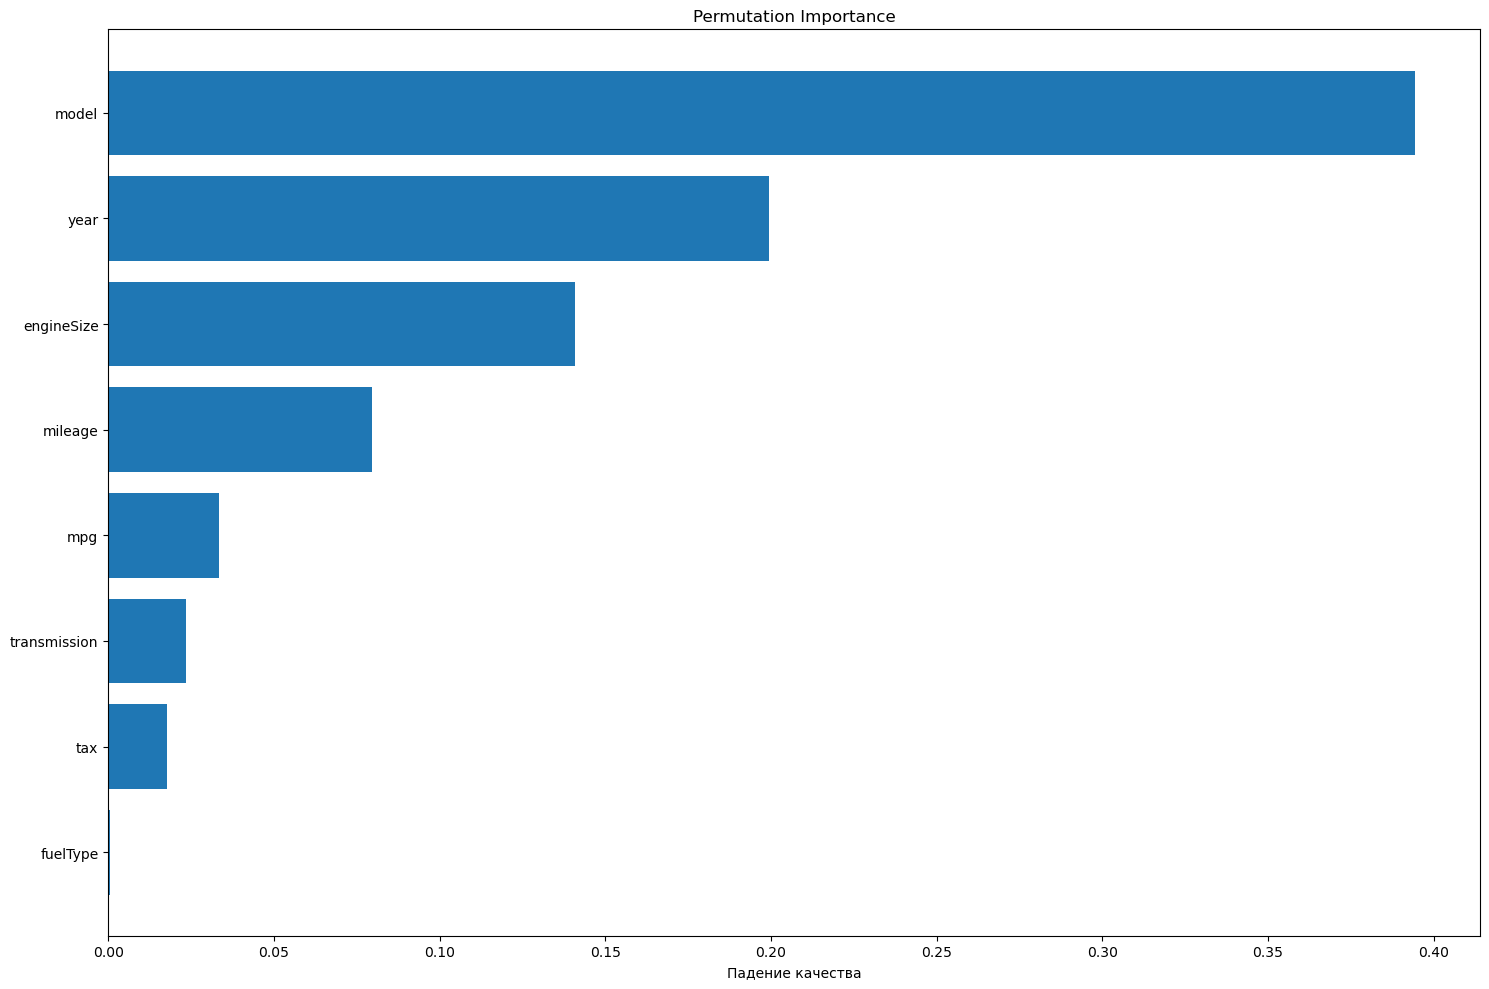

In [211]:
plt.figure(figsize=(15, 10))
plt.barh(importance_df_cat["feature"], importance_df_cat["importance_mean"])
plt.xlabel("Падение качества")
plt.title("Permutation Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [267]:
##Обучаем модель Линейной регрессией
model_lin = LinearRegression()
model_lin.fit(X_train_enc2, y_train)

# Предсказание
y_pred_lin = model_lin.predict(X_test_enc2)

# Метрики
print("MSE:", mean_squared_error(y_test, y_pred_lin))
print("MAE:", mean_absolute_error(y_test, y_pred_lin))
print("R2:", r2_score(y_test, y_pred_lin))


MSE: 9749506.457967972
MAE: 2210.355863094477
R2: 0.8552540112021512


In [83]:
model_reg = SGDRegressor(
    loss="huber",  ## Функция ошибки 
    penalty="l1", ## Регуляризация
    alpha=0.0007,  ## Сила регуляризации
    learning_rate="adaptive", ## по мере обучения шаг уменьшается
    eta0=0.01, ## Начальный шаг обучения
    max_iter=5000,## макс. колво итераций
    tol=1e-5, ## допуск для остановки кода
    random_state=42
)

In [215]:
model_reg.fit(X_train_enc2, y_train)

# Предсказание
y_pred_reg = model_reg.predict(X_test_enc2)

# Метрики
print("MSE:", mean_squared_error(y_test, y_pred_reg))
print("MAE:", mean_absolute_error(y_test, y_pred_reg))
print("R2:", r2_score(y_test, y_pred_reg))

MSE: 14019387.325760636
MAE: 2566.4548444080383
R2: 0.7918612506637391


In [85]:
## Подбор гиперпараметров 
##Сетка параметров
alpha_grid1 = np.logspace(-4,4,10)
param_grid1 = {
    'alpha':alpha_grid1,
    'loss': ['squared_error', 'huber'],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'learning_rate': ['invscaling', 'adaptive'],
    'eta0': [0.01, 0.05, 0.1]
}   
    
##Поиск лучших параметров
grid1 = GridSearchCV(
    estimator=SGDRegressor(),
    param_grid=param_grid1,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

In [80]:
grid1.fit(X_train_enc2, y_train)

Fitting 5 folds for each of 360 candidates, totalling 1800 fits


,estimator,SGDRegressor()
,param_grid,"{'alpha': array([1.0000...00000000e+04]), 'eta0': [0.01, 0.05, ...], 'learning_rate': ['invscaling', 'adaptive'], 'loss': ['squared_error', 'huber'], ...}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'huber'


In [81]:
grid1.best_params_

{'alpha': np.float64(0.000774263682681127),
 'eta0': 0.01,
 'learning_rate': 'adaptive',
 'loss': 'huber',
 'penalty': 'l1'}

In [86]:
result_lin = permutation_importance(model_lin, X_test_enc2, y_test, n_repeats=10, random_state=42)

In [87]:
feature_names=X_test_enc2.columns
feature_names

Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='object')

In [88]:
importance_df_lin = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": result_lin.importances_mean, ## Cреднее падение качества модели
    "importance_std": result_lin.importances_std ## Cтандартное отклонение важности
}).sort_values("importance_mean", ascending=False)
importance_df_lin

,feature,importance_mean,importance_std
0,model,0.394224,0.003310
1,year,0.199443,0.002497
7,engineSize,0.140967,0.001866
3,mileage,0.079604,0.001356
6,mpg,0.033552,0.000759
2,transmission,0.023333,0.000604
5,tax,0.017598,0.000628
4,fuelType,0.000603,0.000092


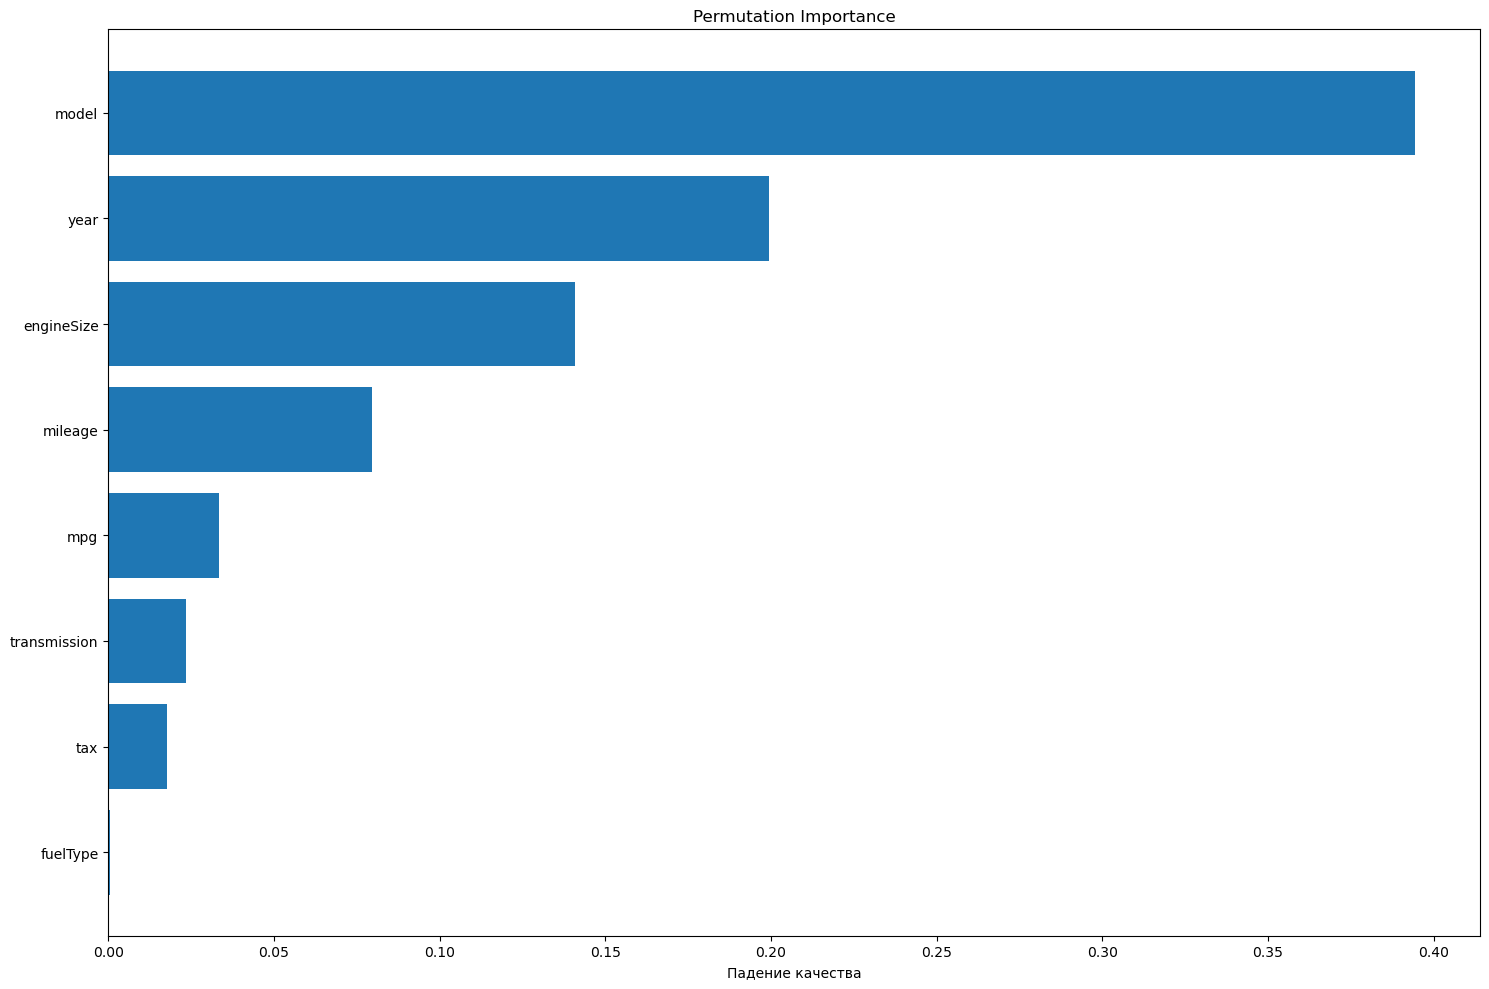

In [35]:
plt.figure(figsize=(15, 10))
plt.barh(importance_df_lin["feature"], importance_df_lin["importance_mean"])
plt.xlabel("Падение качества")
plt.title("Permutation Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [268]:
# Cлучвайный лес
model_forest = ExtraTreesRegressor(
    n_estimators=50,
    random_state=42,
    max_depth=10,
    min_samples_leaf=1,
    min_samples_split=2,
    n_jobs=-1
)

model_forest.fit(X_train_enc2, y_train)
y_pred_forest = model_forest.predict(X_test_enc2)

print("MSE:", mean_squared_error(y_test, y_pred_forest))
print("MAE:", mean_absolute_error(y_test, y_pred_forest))
print("R2:", r2_score(y_test, y_pred_forest))

MSE: 11301517.34997553
MAE: 2482.2818689251953
R2: 0.8322120908590893


In [217]:
importances = pd.Series(model_forest.feature_importances_, index=X_train_enc2.columns)
print(importances.sort_values(ascending=False).head(10))

transmission    0.338295
model           0.277715
year            0.165821
engineSize      0.084975
mileage         0.075557
mpg             0.025595
fuelType        0.020159
tax             0.011883
dtype: float64


In [91]:
result = permutation_importance(model_forest, X_test_enc2, y_test, n_repeats=10, random_state=42)

In [92]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": result.importances_mean, ## Cреднее падение качества модели
    "importance_std": result.importances_std ## Cтандартное отклонение важности
}).sort_values("importance_mean", ascending=False)
importance_df

,feature,importance_mean,importance_std
2,transmission,0.374206,0.006957
0,model,0.230505,0.002652
1,year,0.156377,0.001985
7,engineSize,0.093156,0.001388
3,mileage,0.051042,0.000788
6,mpg,0.016814,0.000492
5,tax,0.004357,0.000294
4,fuelType,-0.012375,0.000698


In [93]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": result.importances_mean, ## Cреднее падение качества модели
    "importance_std": result.importances_std ## Cтандартное отклонение важности
}).sort_values("importance_mean", ascending=False)
importance_df

,feature,importance_mean,importance_std
2,transmission,0.374206,0.006957
0,model,0.230505,0.002652
1,year,0.156377,0.001985
7,engineSize,0.093156,0.001388
3,mileage,0.051042,0.000788
6,mpg,0.016814,0.000492
5,tax,0.004357,0.000294
4,fuelType,-0.012375,0.000698


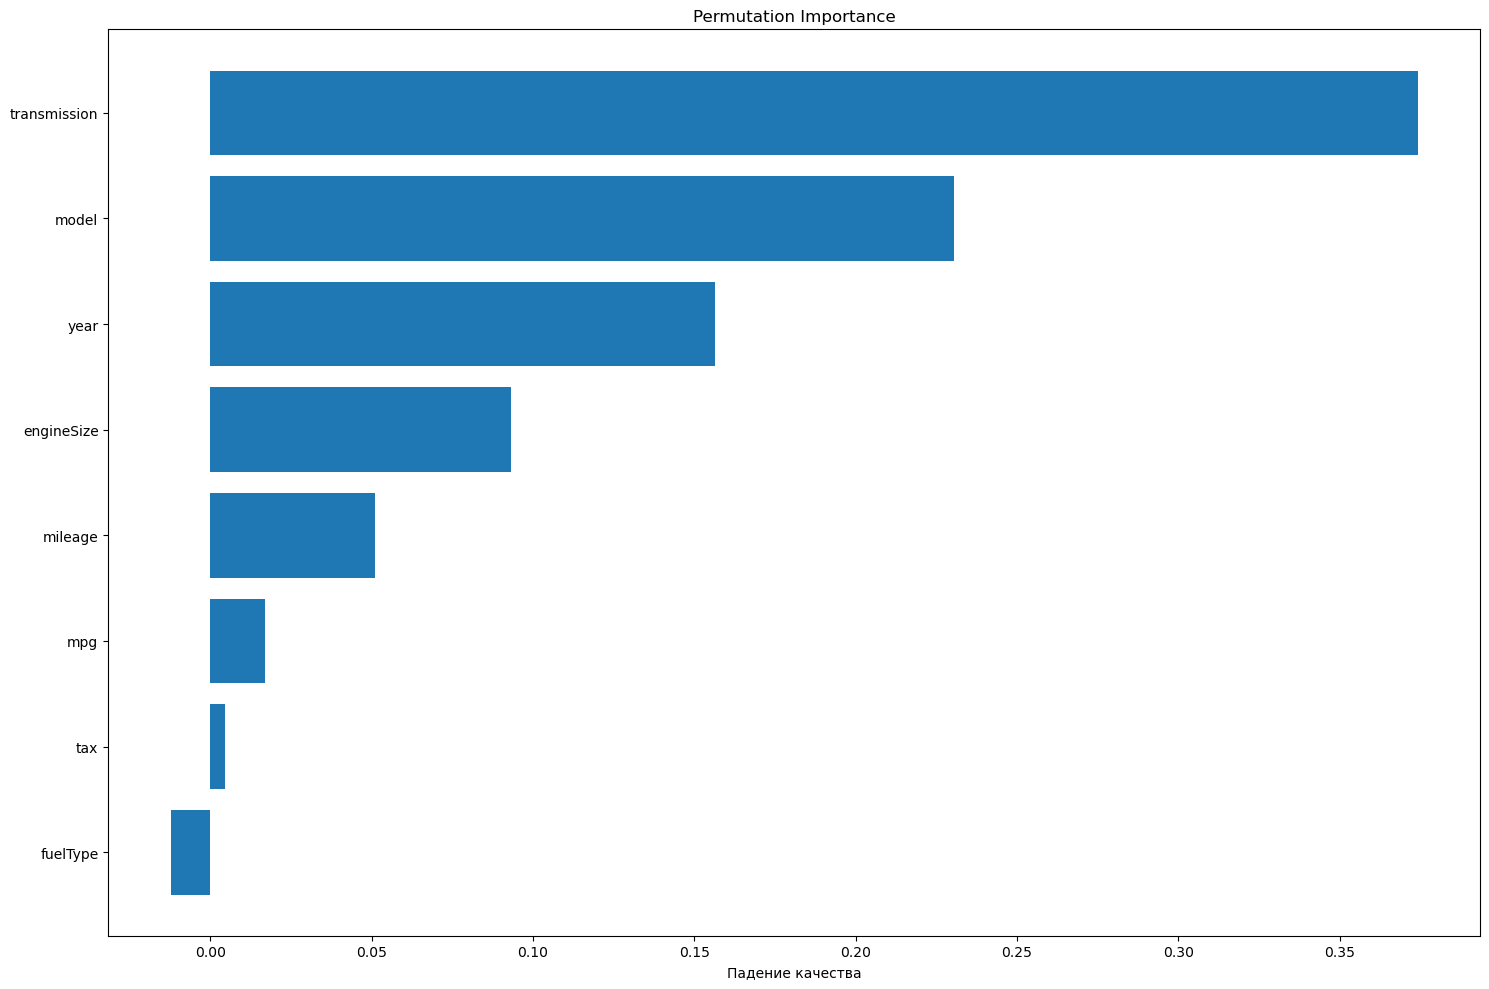

In [94]:
plt.figure(figsize=(15, 10))
plt.barh(importance_df["feature"], importance_df["importance_mean"])
plt.xlabel("Падение качества")
plt.title("Permutation Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [95]:
## Подбор гиперпараметров 
##Сетка параметров
param_grid2 = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [None, 5, 10, 15, 20],
    "max_features": ["sqrt", "log2", ],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
}

##Поиск лучших параметров
grid2 = GridSearchCV(
    estimator=model_forest,
    param_grid=param_grid2,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

In [96]:
grid2.fit(X_train_enc2, y_train)

Fitting 5 folds for each of 640 candidates, totalling 3200 fits


,estimator,ExtraTreesReg...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [97]:
grid2.best_params_

{'max_depth': None,
 'max_features': 'log2',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

In [45]:
## Для общенго датасета наиболее влияемым параметром оказался модель и год машины

In [46]:
## Строим модель стекинга

In [115]:
from sklearn.ensemble import StackingRegressor

In [131]:
##Стекинг
stack_model = StackingRegressor(
    estimators=[
        ("cat", model3),
        ("lin", model_lin),
        ("for", model_forest),
    ],
    final_estimator=Ridge(),
    passthrough=False,
    cv=5)

In [132]:
##Обучаем
stack_model.fit(X_train_enc2, y_train)

##Предсказываем
y_pred = stack_model.predict(X_test_enc2)

##Метрики
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"R2: {r2}")

0:	learn: 3973.9473087	total: 7.48ms	remaining: 7.47s
100:	learn: 253.5537684	total: 609ms	remaining: 5.42s
200:	learn: 177.0542713	total: 1.2s	remaining: 4.76s
300:	learn: 143.6036664	total: 1.78s	remaining: 4.12s
400:	learn: 128.0473940	total: 2.36s	remaining: 3.52s
500:	learn: 115.5463876	total: 2.95s	remaining: 2.94s
600:	learn: 106.1200737	total: 3.54s	remaining: 2.35s
700:	learn: 100.2157413	total: 4.12s	remaining: 1.76s
800:	learn: 95.1563767	total: 4.7s	remaining: 1.17s
900:	learn: 91.7506259	total: 5.28s	remaining: 580ms
999:	learn: 88.5639836	total: 5.87s	remaining: 0us
0:	learn: 3861.5963222	total: 5.86ms	remaining: 5.85s
100:	learn: 260.7277494	total: 538ms	remaining: 4.78s
200:	learn: 180.9879896	total: 1.05s	remaining: 4.17s
300:	learn: 150.7868862	total: 1.55s	remaining: 3.6s
400:	learn: 134.6430588	total: 2.05s	remaining: 3.07s
500:	learn: 123.3322853	total: 2.55s	remaining: 2.54s
600:	learn: 112.8705728	total: 3.07s	remaining: 2.04s
700:	learn: 105.8161025	total: 3.57s

In [ ]:
##Уровень 3

In [118]:
def fit_stacking(X_train, y_train, base_models, final_model, n_splits=5):
    """
    Обучает стекинг.
    base_models: [(name, model), ...]
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42) ## разбиение на фолды
    n_samples = len(X_train)
    n_base = len(base_models)

    meta_features = np.zeros((n_samples, n_base)) ## Матрица предсказаний  базовых моделей
    trained_base_models = [] ## Список для сохраненийя обученных моделей каждого фолда

    for idx, (name, model) in enumerate(base_models):
        print(f"\n{'='*40}")
        print(f"Базовая модель {idx+1}/{n_base}: {name}")
        print(f"{'='*40}")
        
##OOF -(out of fold)-  предсказания модели на тех данных, которые не использовались для её обучения в текущей итерации кросс‑валидации
        
        oof_preds = np.zeros(n_samples) ## Передсказания внутри одной модели
        fold_models = [] ## Собираются предсказания для всех обЬектов train

        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)): ## список для сохранения 5 обученных моделей этого фолда 
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

            # Копия модели с теми же параметрами - для того чтобы каждый фолд изучал независимую модель
            fold_model = model.__class__(**model.get_params())## rkdcc
            fold_model.fit(X_tr, y_tr)

            oof_preds[val_idx] = fold_model.predict(X_val) ## После обучения всех фолдов будетсодержать предсказания для всех объектов train 
            fold_models.append(fold_model)

            fold_mse = mean_squared_error(y_val, oof_preds[val_idx])
            print(f"  Fold {fold+1}/{n_splits}: MSE = {fold_mse:.2f}")

        trained_base_models.append({
            'name': name,
            'fold_models': fold_models
        })##  словарь с именем и списком из  5 обученных моделей

        meta_features[:, idx] = oof_preds ## мета-прзнаки
        print(f"  »> Средний OOF MSE: {mean_squared_error(y_train, oof_preds):.2f}")

    # Финальная модель
    print(f"\n{'='*40}")
    print(f"Финальная модель: {final_model.__class__.__name__}")
    print(f"{'='*40}")
    final_model.fit(meta_features, y_train)

    train_pred = final_model.predict(meta_features)
    print(f"  MSE на train-meta: {mean_squared_error(y_train, train_pred):.2f}")

    return trained_base_models, final_model

def predict_stacking(X_test, trained_base_models, final_model):
    """
    Предсказание стекинга.
    """
    n_samples = len(X_test)
    n_base = len(trained_base_models)

    meta_features_test = np.zeros((n_samples, n_base))

    print(f"\n{'='*40}")
    print(f"Предсказание базовых моделей")
    print(f"{'='*40}")

    for idx, base_info in enumerate(trained_base_models):
        name = base_info['name']
        fold_models = base_info['fold_models']

        preds = np.zeros(n_samples)
        for fold_model in fold_models:
            preds += fold_model.predict(X_test) ##Усреднение фолд-моделей

        preds /= len(fold_models)
        meta_features_test[:, idx] = preds

        print(f"  {name}: mean = {preds.mean():.2f}, std = {preds.std():.2f}")

    final_predictions = final_model.predict(meta_features_test)

    return final_predictions


In [119]:

# Список базовых моделей: 
base_models = [
        ("catbbost", model3),
        ("linregression", model_lin),
        ("forest", model_forest)
]

# Финальная модель
final_model = LinearRegression()

## Обучение стекинга

trained_base, trained_final = fit_stacking(
    X_train_enc2, y_train,
    base_models=base_models,
    final_model=final_model,
    n_splits=5
)

y_pred_stc = predict_stacking(X_test_enc2, trained_base, trained_final) ##ПРЕДСКАЗАНИЕ

##МЕТРИКИ
print(f"MSE:  {mean_squared_error(y_test, y_pred_stc):.2f}")
print(f"R2:   {r2_score(y_test, y_pred_stc):.4f}")


Базовая модель 1/3: catbbost
0:	learn: 3988.7321109	total: 5.71ms	remaining: 5.7s
100:	learn: 247.0656808	total: 521ms	remaining: 4.63s
200:	learn: 165.4420931	total: 1.03s	remaining: 4.12s
300:	learn: 139.0323736	total: 1.57s	remaining: 3.64s
400:	learn: 123.9415632	total: 2.09s	remaining: 3.12s
500:	learn: 112.1209999	total: 2.59s	remaining: 2.58s
600:	learn: 103.9253960	total: 3.09s	remaining: 2.05s
700:	learn: 97.7721808	total: 3.58s	remaining: 1.53s
800:	learn: 92.9623739	total: 4.07s	remaining: 1.01s
900:	learn: 89.5049948	total: 4.57s	remaining: 502ms
999:	learn: 86.1247814	total: 5.05s	remaining: 0us
  Fold 1/5: MSE = 309718.29
0:	learn: 3929.0708917	total: 5.4ms	remaining: 5.4s
100:	learn: 255.8515652	total: 509ms	remaining: 4.53s
200:	learn: 184.5442602	total: 1000ms	remaining: 3.97s
300:	learn: 151.2013204	total: 1.49s	remaining: 3.46s
400:	learn: 133.7625467	total: 1.99s	remaining: 2.97s
500:	learn: 122.4241971	total: 2.47s	remaining: 2.46s
600:	learn: 111.2649963	total: 2